Loaded 900 signal pairs, length 8000, fs=8000 Hz
Classification set (augmented): (5400, 64, 64)
Clean spectrograms A / B      : (900, 64, 64) / (900, 64, 64)
Absolute energies A / B       : (900,) / (900,)
Saved: ../data/spectrograms.npz
Saved: ../results/figures/example_spectrograms.png and example_spectrograms.pdf


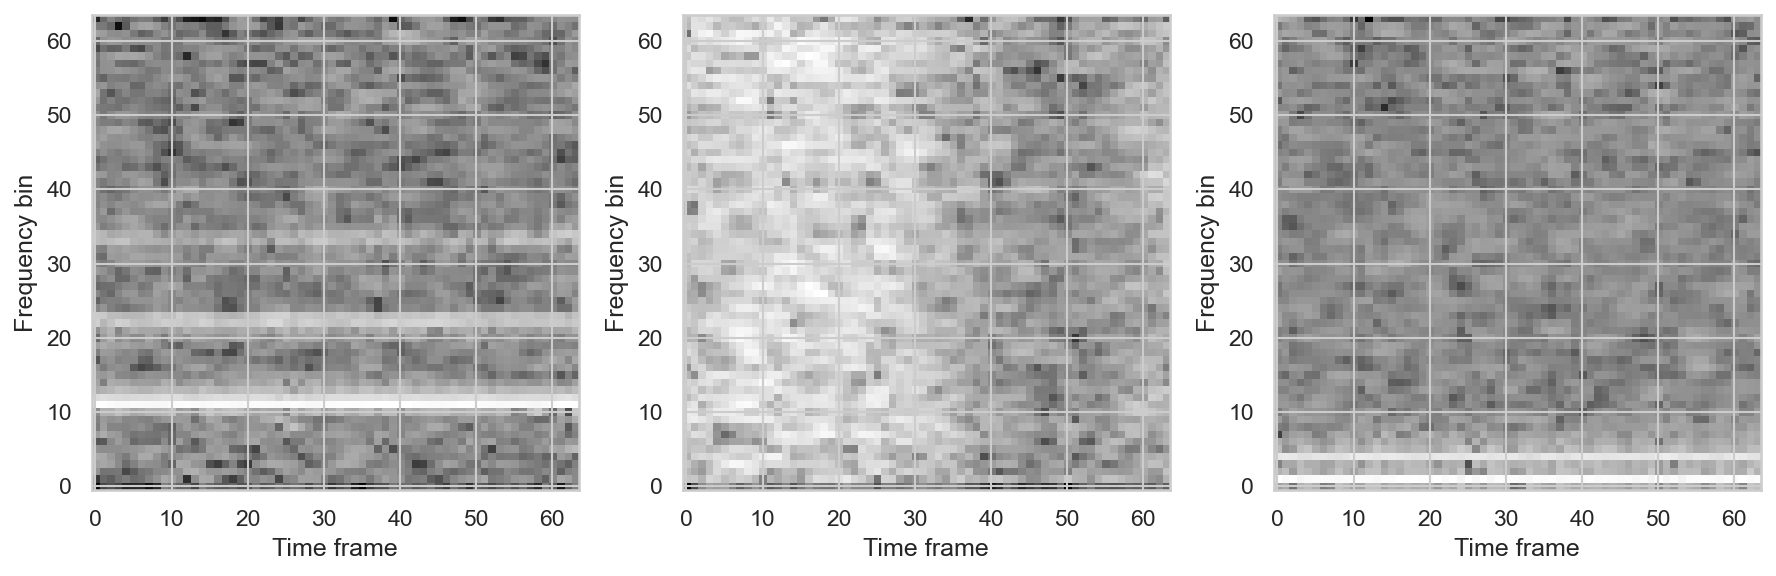

Saved: ../results/figures/example_augmentation.png and example_augmentation.pdf


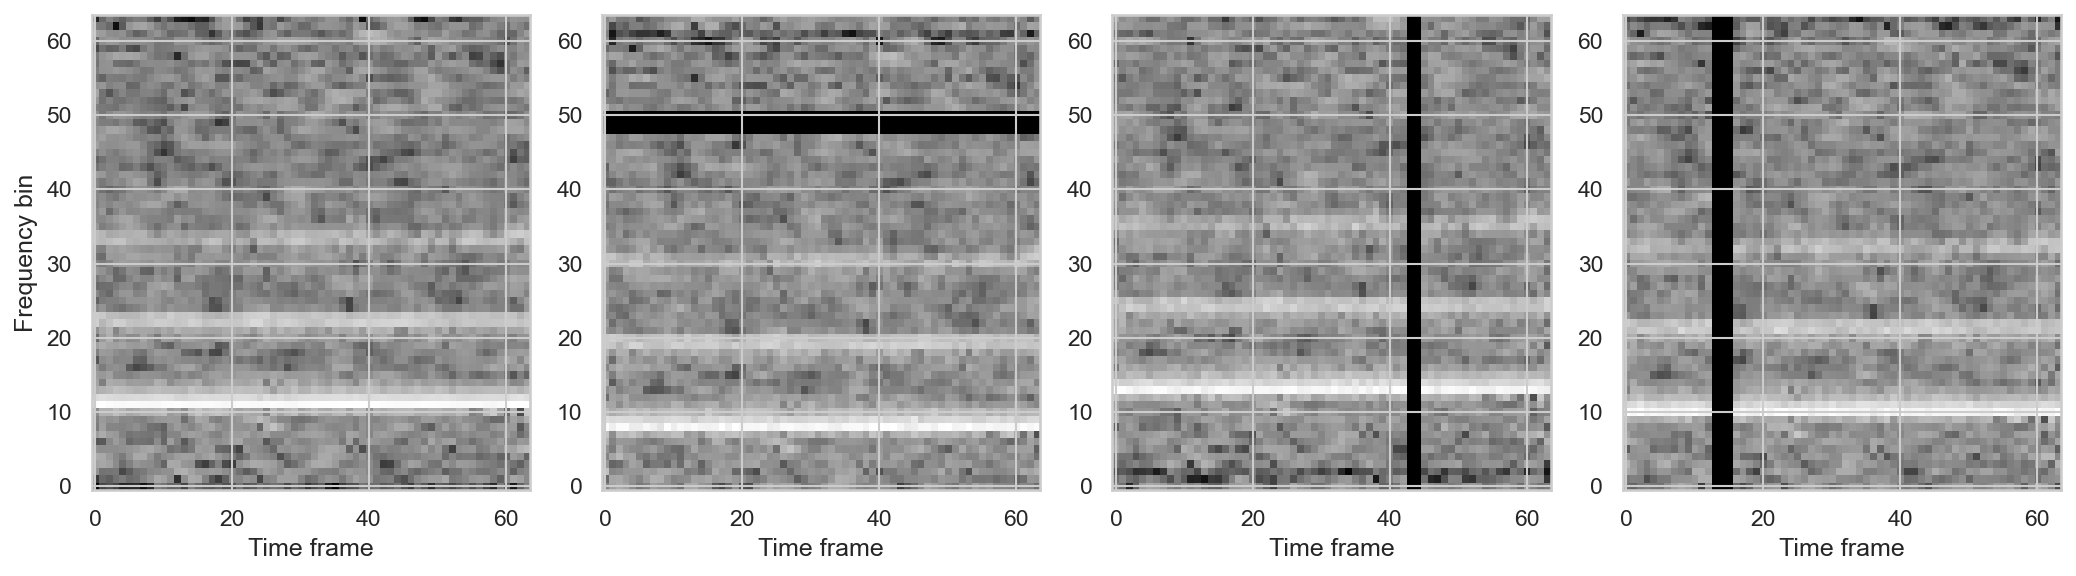

In [4]:
# ============================================================
# Notebook: 02_preprocessing_spectrogram.ipynb
# Purpose : Extract the least-noisy segment from each signal,
#           convert it to a grayscale spectrogram image, and apply
#           data augmentation to mitigate overfitting. Spectrograms
#           serve as the input for the CNN classifier (notebook 03)
#           and as the basis for correlation / localization (04).
#
#           IMPORTANT: per-image [0,1] normalization destroys the
#           relative energy between points A and B, which localization
#           depends on. We therefore ALSO store the pre-normalization
#           absolute pattern energy of each spectrogram, so that
#           notebook 04 can recover E_A / E_B on a common physical
#           scale while classification still uses normalized images.
# Inputs  : ../data/signals.npz
#           ../data/labels.csv
# Outputs : ../data/spectrograms.npz     (images + absolute energies)
#           ../results/figures/          (example spectrogram figures)
# ============================================================

# ------------------------------------------------------------
# Cell 1 — Imports, configuration, and plotting helper
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sp_signal

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = "../data"
FIG_DIR = "../results/figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Global plotting style: seaborn, grayscale
sns.set_theme(style="whitegrid")
sns.set_palette("gray")
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.dpi"] = 150

# Helper: save a figure as both PNG and PDF at 600 dpi, no title/caption
def save_figure(fig, name, fig_dir=FIG_DIR, dpi=600):
    for ext in ("png", "pdf"):
        path = os.path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {fig_dir}/{name}.png and {name}.pdf")


# ------------------------------------------------------------
# Cell 2 — Load signals and labels
# ------------------------------------------------------------
data = np.load(os.path.join(DATA_DIR, "signals.npz"))
signals_A = data["signals_A"]
signals_B = data["signals_B"]
FS = int(data["fs"])
t = data["t"]

labels_df = pd.read_csv(os.path.join(DATA_DIR, "labels.csv"))

N_SAMPLES = signals_A.shape[1]
print(f"Loaded {signals_A.shape[0]} signal pairs, length {N_SAMPLES}, fs={FS} Hz")


# ------------------------------------------------------------
# Cell 3 — Least-noisy segment extraction
# ------------------------------------------------------------
# The original methodology scans the signal at a fixed interval and
# selects the first window whose amplitude stays within a reference
# range (i.e., the quietest, most stationary portion), avoiding
# transient noise bursts. We slide a window across the signal and
# pick the window with the lowest amplitude variance as the
# least-noisy, most stationary segment.
SEG_DURATION = 0.25                       # segment length [s]
SEG_LEN = int(FS * SEG_DURATION)          # segment length [samples]
STEP = int(FS * 0.05)                     # scan step (0.05 s) [samples]

def extract_least_noisy_segment(sig, seg_len=SEG_LEN, step=STEP):
    best_start = 0
    best_var = np.inf
    for start in range(0, len(sig) - seg_len + 1, step):
        window = sig[start:start + seg_len]
        var = np.var(window)              # variance as a noise proxy
        if var < best_var:
            best_var = var
            best_start = start
    return sig[best_start:best_start + seg_len]


# ------------------------------------------------------------
# Cell 4 — Spectrogram conversion (image + absolute energy)
# ------------------------------------------------------------
# Convert a 1-D segment to a 2-D spectrogram (time x frequency) in
# decibels. We return TWO things:
#   (1) img       : per-image [0,1] normalized, resized grayscale
#                   spectrogram for the CNN classifier and for
#                   correlation-based same-pipe decisions.
#   (2) abs_energy: the absolute leak-pattern energy computed on the
#                   spectrogram BEFORE per-image normalization. This
#                   preserves the true A-vs-B energy scale that the
#                   localization models require.
#
# The absolute energy is defined as the mean linear power over the
# strongest spectrogram cells (the "leak pattern"), matching the
# methodology's "average energy of the extracted leak pattern".
NPERSEG = 128
NOVERLAP = 96
IMG_SIZE = 64          # spectrograms are resized to IMG_SIZE x IMG_SIZE
ENERGY_PERCENTILE = 75 # keep the strongest 25% of cells as leak pattern

def signal_to_spectrogram(seg, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP,
                          img_size=IMG_SIZE, energy_pct=ENERGY_PERCENTILE):
    f, tt, Sxx = sp_signal.spectrogram(seg, fs=fs, nperseg=nperseg,
                                       noverlap=noverlap)

    # (2) Absolute pattern energy on the LINEAR power spectrogram,
    #     computed before any per-image normalization. This is the
    #     physical quantity used by localization.
    thr = np.percentile(Sxx, energy_pct)
    pattern = Sxx[Sxx >= thr]
    abs_energy = float(pattern.mean()) if pattern.size > 0 else float(Sxx.mean())

    # (1) Normalized image for classification / correlation.
    Sxx_db = 10 * np.log10(Sxx + 1e-12)              # to decibels
    Sxx_norm = (Sxx_db - Sxx_db.min()) / (np.ptp(Sxx_db) + 1e-12)
    img = _resize_2d(Sxx_norm, img_size, img_size)

    return img, abs_energy

def _resize_2d(arr, out_h, out_w):
    # Lightweight bilinear-ish resize using np.interp along both axes,
    # avoiding an extra image library dependency.
    in_h, in_w = arr.shape
    row_idx = np.linspace(0, in_h - 1, out_h)
    col_idx = np.linspace(0, in_w - 1, out_w)
    # interpolate along columns first
    tmp = np.empty((in_h, out_w))
    for i in range(in_h):
        tmp[i] = np.interp(col_idx, np.arange(in_w), arr[i])
    # then along rows
    out = np.empty((out_h, out_w))
    for j in range(out_w):
        out[:, j] = np.interp(row_idx, np.arange(in_h), tmp[:, j])
    return out


# ------------------------------------------------------------
# Cell 5 — Data augmentation
# ------------------------------------------------------------
# To reduce overfitting and improve generalization, each spectrogram
# is augmented into several variants. Augmentations are mild and
# label-preserving: additive Gaussian noise, small time/frequency
# shifts, and random time/frequency masking (SpecAugment-style).
# Augmentation is applied ONLY to the normalized images used for
# classification; it never touches the absolute energies used for
# localization.
N_AUG = 5              # number of augmented copies per spectrogram

def augment_spectrogram(img, rng):
    aug = img.copy()
    # 1) additive Gaussian noise
    aug = aug + rng.normal(0, 0.02, size=aug.shape)
    # 2) small circular shift in time and frequency
    shift_t = rng.integers(-3, 4)
    shift_f = rng.integers(-3, 4)
    aug = np.roll(aug, shift=(shift_f, shift_t), axis=(0, 1))
    # 3) random time mask
    if rng.random() < 0.5:
        w = rng.integers(2, 6)
        c = rng.integers(0, aug.shape[1] - w)
        aug[:, c:c + w] = 0.0
    # 4) random frequency mask
    if rng.random() < 0.5:
        h = rng.integers(2, 6)
        c = rng.integers(0, aug.shape[0] - h)
        aug[c:c + h, :] = 0.0
    return np.clip(aug, 0.0, 1.0)


# ------------------------------------------------------------
# Cell 6 — Build spectrogram dataset
# ------------------------------------------------------------
# For classification (notebook 03) we use point-A normalized
# spectrograms with augmentation. For localization (notebook 04) we
# keep, for BOTH points A and B:
#   - clean normalized spectrograms  (for correlation / same-pipe)
#   - absolute pattern energies      (for the localization models)
# Augmentation is applied only to the classification images.
spec_images = []       # augmented normalized spectrograms (A) for classifier
spec_labels = []       # matching class labels
spec_ids = []          # source sample id for traceability

specA_clean = []       # clean normalized spectrograms at A (correlation)
specB_clean = []       # clean normalized spectrograms at B (correlation)
energyA = []           # absolute pattern energy at A (localization)
energyB = []           # absolute pattern energy at B (localization)

for i in range(signals_A.shape[0]):
    label = labels_df.loc[i, "label"]

    segA = extract_least_noisy_segment(signals_A[i])
    segB = extract_least_noisy_segment(signals_B[i])

    imgA, eA = signal_to_spectrogram(segA)
    imgB, eB = signal_to_spectrogram(segB)

    # store clean normalized spectrograms + absolute energies
    specA_clean.append(imgA)
    specB_clean.append(imgB)
    energyA.append(eA)
    energyB.append(eB)

    # store original + augmented normalized spectrograms for classifier
    spec_images.append(imgA)
    spec_labels.append(label)
    spec_ids.append(i)
    for _ in range(N_AUG):
        spec_images.append(augment_spectrogram(imgA, rng))
        spec_labels.append(label)
        spec_ids.append(i)

spec_images = np.array(spec_images, dtype=np.float32)
spec_labels = np.array(spec_labels)
spec_ids = np.array(spec_ids)
specA_clean = np.array(specA_clean, dtype=np.float32)
specB_clean = np.array(specB_clean, dtype=np.float32)
energyA = np.array(energyA, dtype=np.float64)
energyB = np.array(energyB, dtype=np.float64)

print(f"Classification set (augmented): {spec_images.shape}")
print(f"Clean spectrograms A / B      : {specA_clean.shape} / {specB_clean.shape}")
print(f"Absolute energies A / B       : {energyA.shape} / {energyB.shape}")


# ------------------------------------------------------------
# Cell 7 — Save spectrogram dataset
# ------------------------------------------------------------
np.savez_compressed(
    os.path.join(DATA_DIR, "spectrograms.npz"),
    spec_images=spec_images,
    spec_labels=spec_labels,
    spec_ids=spec_ids,
    specA_clean=specA_clean,
    specB_clean=specB_clean,
    energyA=energyA,
    energyB=energyB,
    img_size=IMG_SIZE,
)
print("Saved: ../data/spectrograms.npz")


# ------------------------------------------------------------
# Cell 8 — Plot one example spectrogram per class (sanity check)
# ------------------------------------------------------------
# Grayscale spectrogram images, no titles/captions.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cls in zip(axes, ["leak", "consumption", "other"]):
    idx = np.where(labels_df["label"].values == cls)[0][0]
    ax.imshow(specA_clean[idx], origin="lower", aspect="auto", cmap="gray")
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Frequency bin")
plt.tight_layout()
save_figure(fig, "example_spectrograms")
plt.show()


# ------------------------------------------------------------
# Cell 9 — Plot augmentation examples for one signal (sanity check)
# ------------------------------------------------------------
# Show the original spectrogram and several augmented variants.
base_idx = np.where(labels_df["label"].values == "leak")[0][0]
base_img, _ = signal_to_spectrogram(
    extract_least_noisy_segment(signals_A[base_idx]))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(base_img, origin="lower", aspect="auto", cmap="gray")
axes[0].set_xlabel("Time frame")
axes[0].set_ylabel("Frequency bin")
for k in range(1, 4):
    aug_img = augment_spectrogram(base_img, rng)
    axes[k].imshow(aug_img, origin="lower", aspect="auto", cmap="gray")
    axes[k].set_xlabel("Time frame")
plt.tight_layout()
save_figure(fig, "example_augmentation")
plt.show()